In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Major Project_Seasonal Agriculture Performance Analysis.pdf to Major Project_Seasonal Agriculture Performance Analysis.pdf


In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [13]:
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [14]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [15]:
print("Rainfall median:", df['Rainfall_mm'].median())
print("Soil moisture median:", df['Soil_Moisture_pct'].median())
print("Yield median:", df['Yield_Tonnes_Ha'].median())

Rainfall median: 582.0
Soil moisture median: 26.4
Yield median: 1.74


In [16]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [17]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [18]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Rows: 4000
Columns: 28
Missing values: 0
Duplicate rows: 0


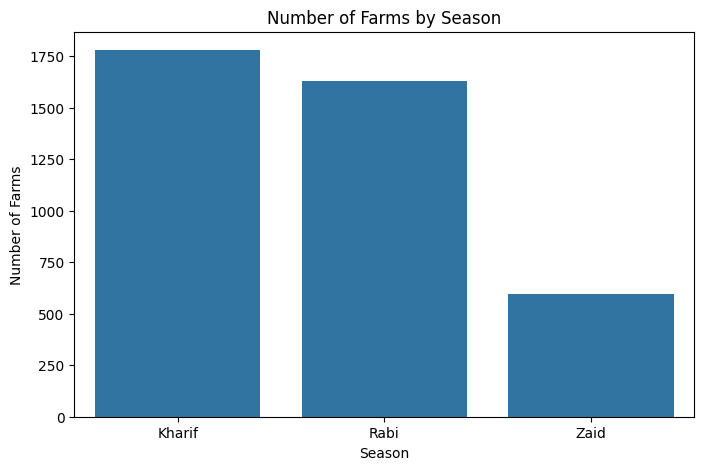

In [19]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")

plt.show()

In [20]:
season_percentage = (
    df['Season']
    .value_counts(normalize=True)
    .mul(100)
)

print(season_percentage.round(2))

Season
Kharif    44.47
Rabi      40.67
Zaid      14.85
Name: proportion, dtype: float64


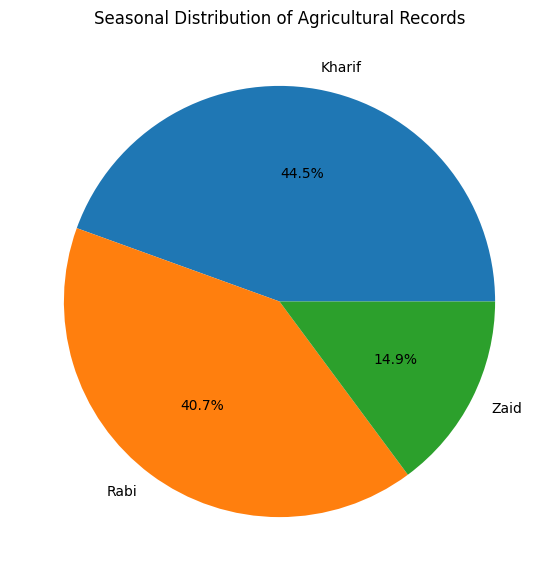

In [21]:
plt.figure(figsize=(7,7))

plt.pie(
    season_percentage.values,
    labels=season_percentage.index,
    autopct='%1.1f%%'
)

plt.title("Seasonal Distribution of Agricultural Records")

plt.show()

In [22]:
season_yield = (
    df.groupby('Season')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


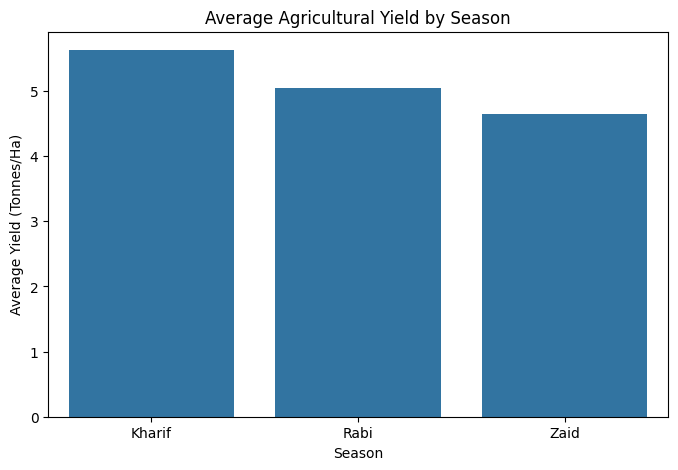

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.show()

### Observation

The average agricultural yield differs across Kharif, Rabi and Zaid seasons.
The season with the highest average yield can be identified from the above
comparison.


In [24]:
season_revenue = (
    df.groupby('Season')['Revenue_INR']
    .mean()
    .sort_values(ascending=False)
)

print(season_revenue)

Season
Kharif    710719.055649
Rabi      601526.048556
Zaid      519171.904040
Name: Revenue_INR, dtype: float64


In [25]:
season_cost = (
    df.groupby('Season')['Total_Cost_INR']
    .mean()
    .sort_values(ascending=False)
)

print(season_cost)

Season
Zaid      543976.728956
Kharif    531804.408094
Rabi      513836.578365
Name: Total_Cost_INR, dtype: float64


In [26]:
season_profit = (
    df.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


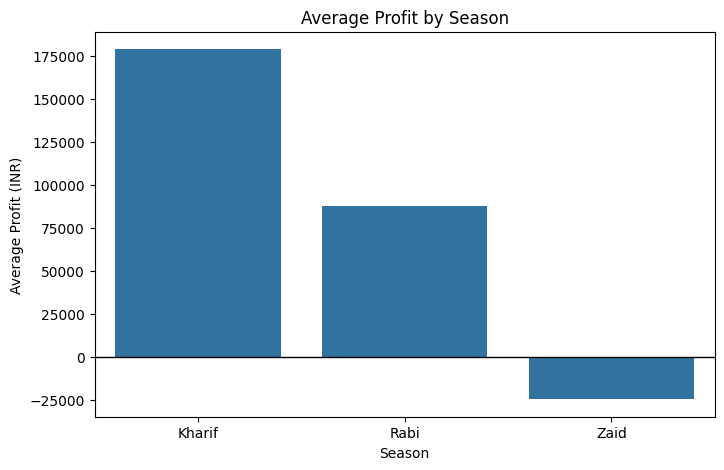

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

plt.axhline(0, color='black', linewidth=1)

plt.show()

In [28]:
season_economics = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

season_economics

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.055649,531804.408094,178914.647555
Rabi,601526.048556,513836.578365,87689.470191
Zaid,519171.904040,543976.728956,-24804.824916


In [29]:
season_economics.round(2)

,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,
Kharif,710719.06,531804.41,178914.65
Rabi,601526.05,513836.58,87689.47
Zaid,519171.90,543976.73,-24804.82


In [30]:
water_usage = (
    df.groupby('Season')['Water_Used_m3']
    .mean()
    .sort_values(ascending=False)
)

print(water_usage)

Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64


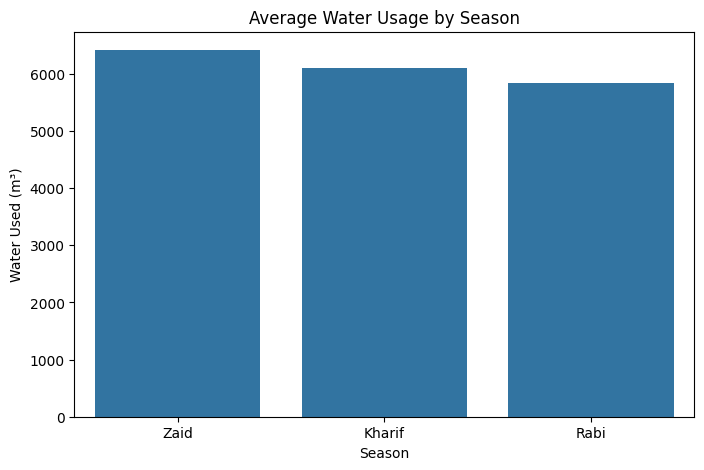

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_usage.index,
    y=water_usage.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.show()

In [32]:
water_efficiency = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


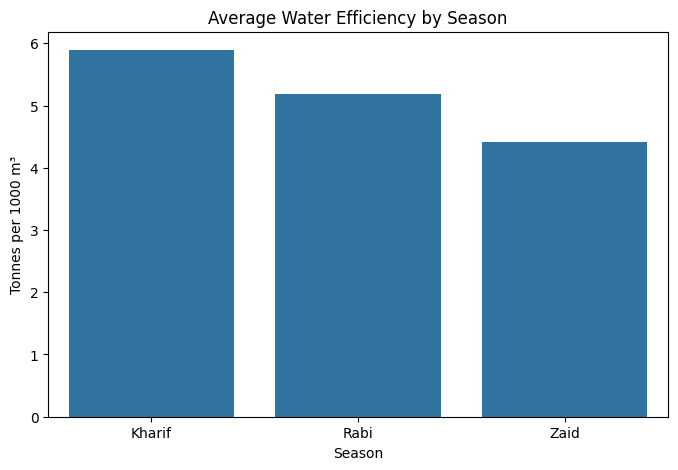

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")

plt.show()

In [34]:
environmental_summary = df.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean()

environmental_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


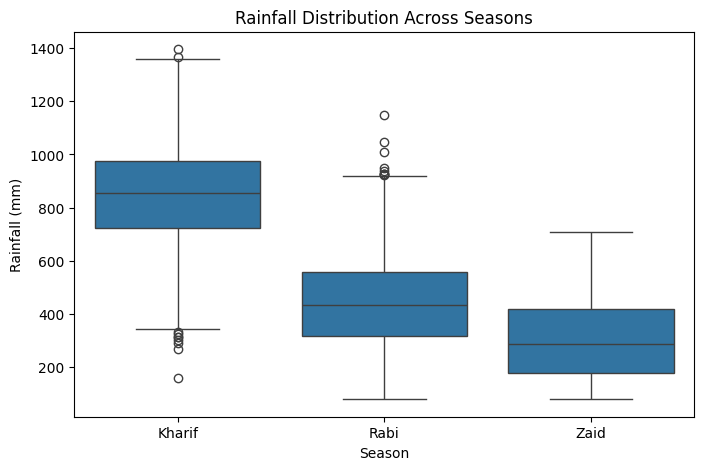

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Rainfall_mm'
)

plt.title("Rainfall Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.show()

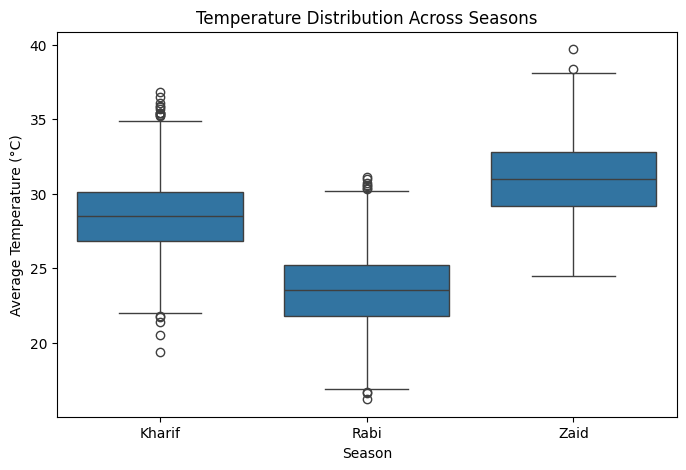

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Avg_Temperature_C'
)

plt.title("Temperature Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.show()

In [37]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


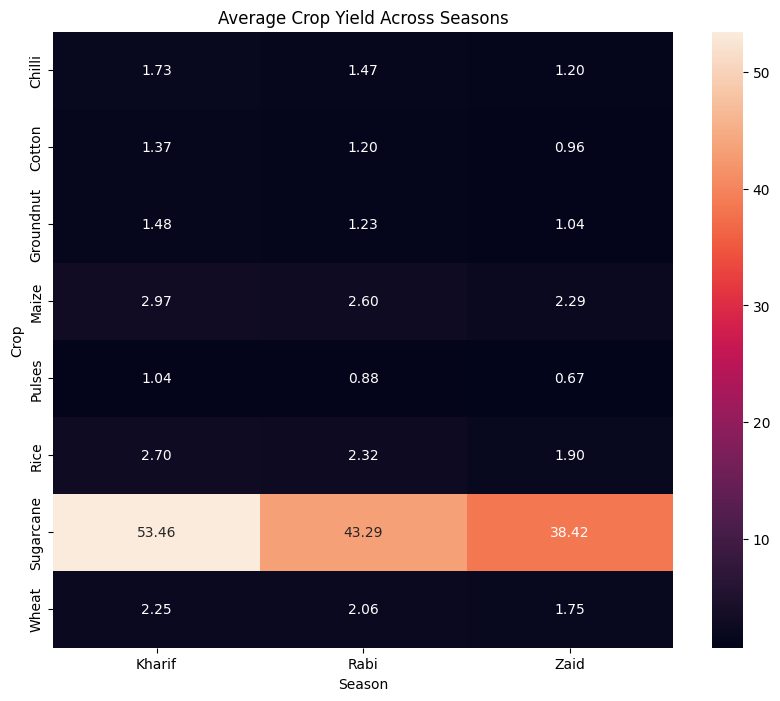

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)
plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [39]:
for season in df['Season'].unique():

    result = (
        df[df['Season'] == season]
        .groupby('Crop')['Yield_Tonnes_Ha']
        .mean()
        .sort_values(ascending=False)
    )

    print("\n", season)
    print(result.head(5))


 Kharif
Crop
Sugarcane    53.459120
Maize         2.966410
Rice          2.698376
Wheat         2.253664
Chilli        1.731459
Name: Yield_Tonnes_Ha, dtype: float64

 Rabi
Crop
Sugarcane    43.286124
Maize         2.603648
Rice          2.322847
Wheat         2.057468
Chilli        1.465031
Name: Yield_Tonnes_Ha, dtype: float64

 Zaid
Crop
Sugarcane    38.423922
Maize         2.290952
Rice          1.900490
Wheat         1.748588
Chilli        1.195312
Name: Yield_Tonnes_Ha, dtype: float64


In [40]:
rrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(irrigation_yield)

Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64


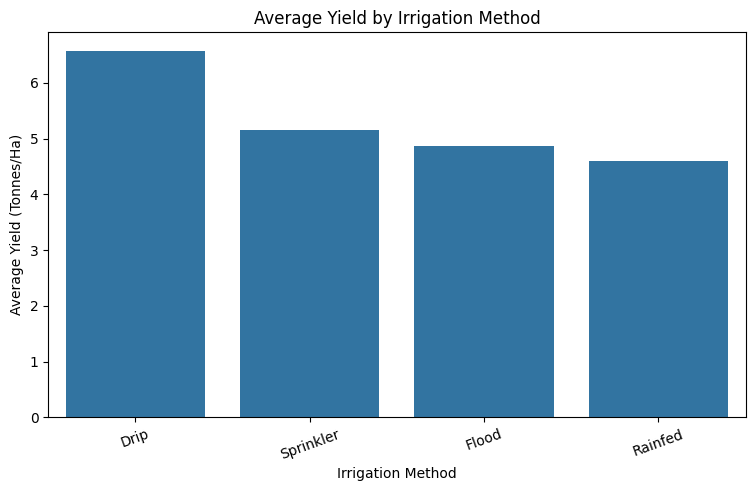

In [41]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_yield.index,
    y=irrigation_yield.values
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=20)

plt.show()

In [42]:
irrigation_efficiency = df.groupby(
    'Irrigation_Method'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(
    ascending=False
)

print(irrigation_efficiency)

Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64


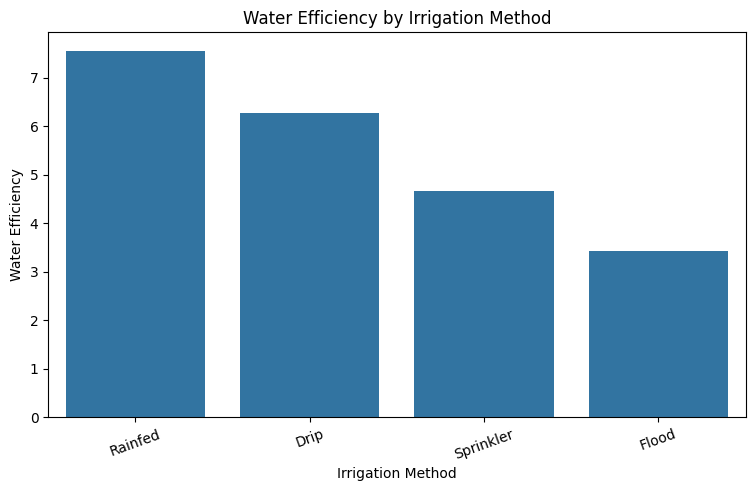

In [43]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=irrigation_efficiency.index,
    y=irrigation_efficiency.values
)

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")

plt.xticks(rotation=20)

plt.show()

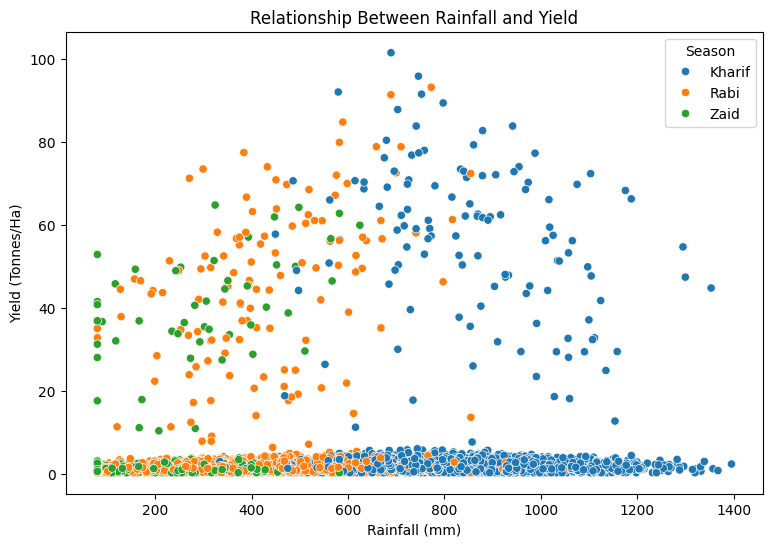

In [44]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [45]:
rainfall_yield_corr = df[
    ['Rainfall_mm', 'Yield_Tonnes_Ha']
].corr()

rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030951
Yield_Tonnes_Ha,0.030951,1.000000


In [46]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,...,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,...,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,...,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,...,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,...,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,...,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


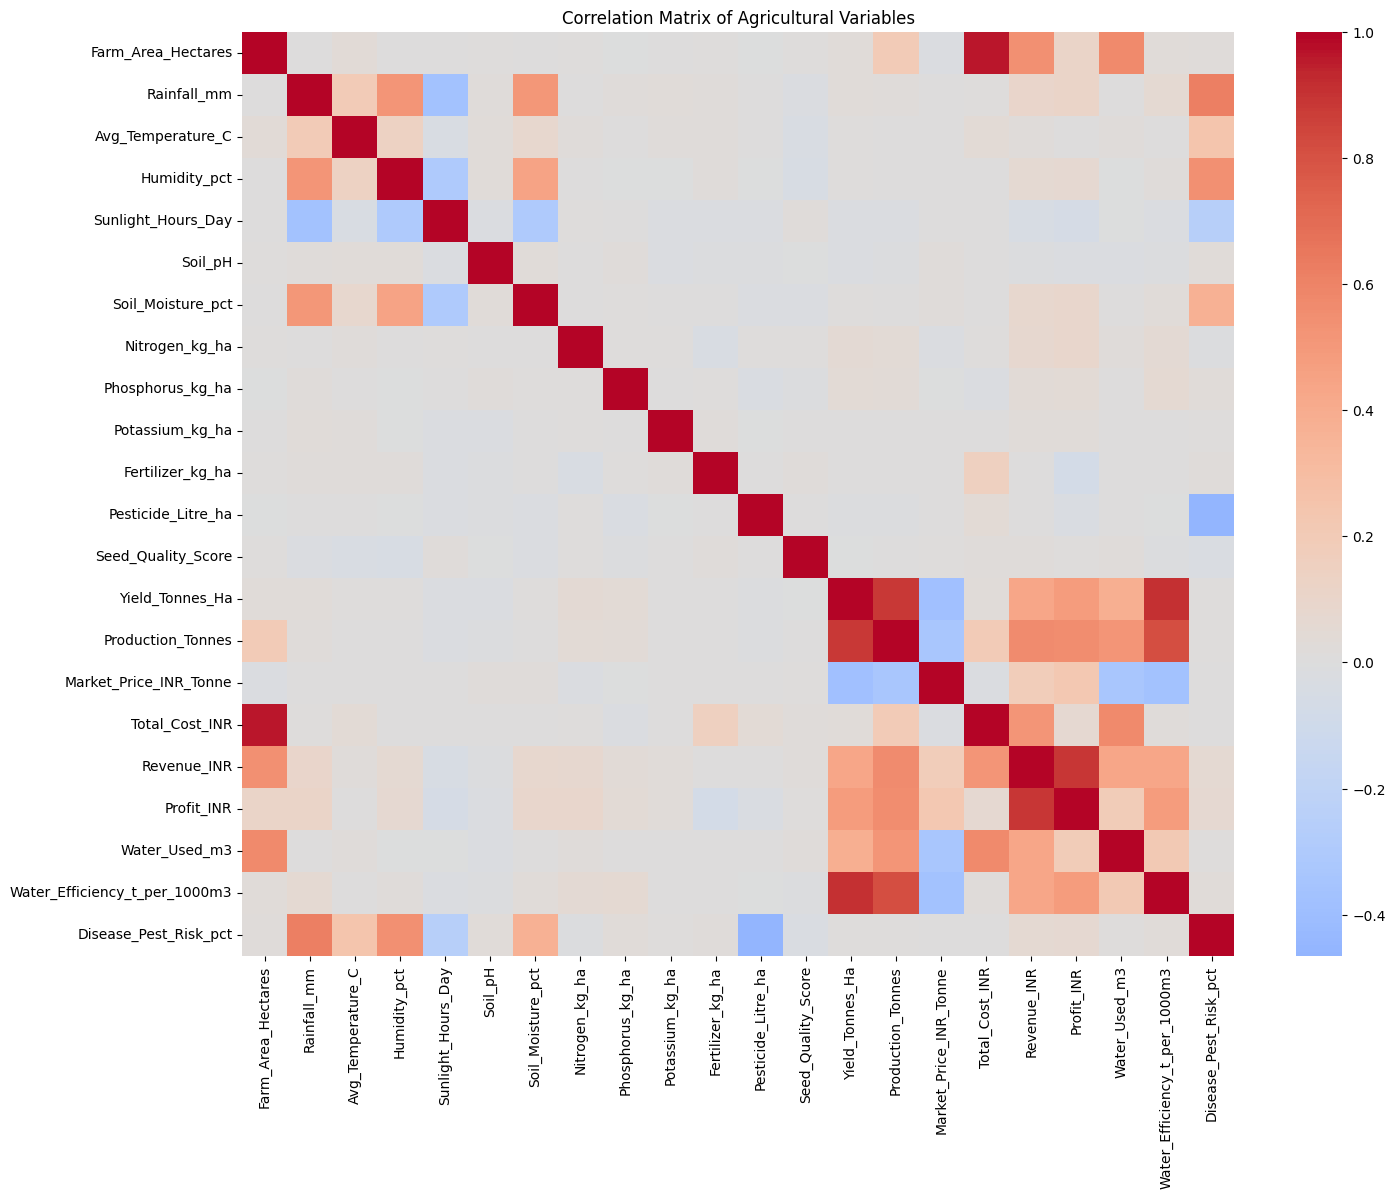

In [47]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.show()

In [48]:
yield_correlation = (
    correlation['Yield_Tonnes_Ha']
    .sort_values(ascending=False)
)

print(yield_correlation)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64


In [49]:
risk_by_season = df.groupby(
    'Season'
)['Disease_Pest_Risk_pct'].mean().sort_values(
    ascending=False
)

print(risk_by_season)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


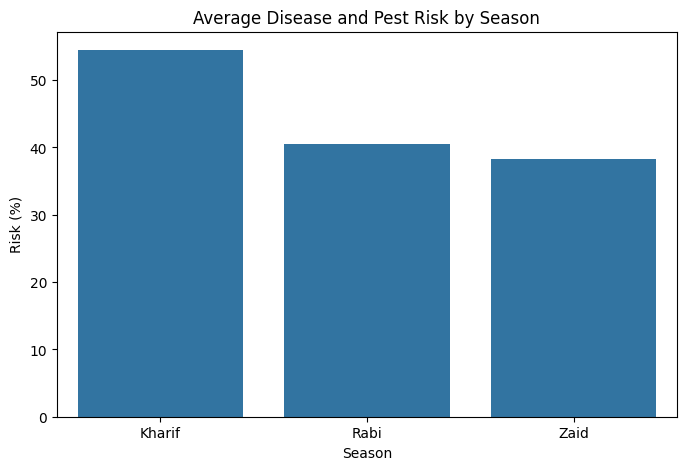

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=risk_by_season.index,
    y=risk_by_season.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.show()

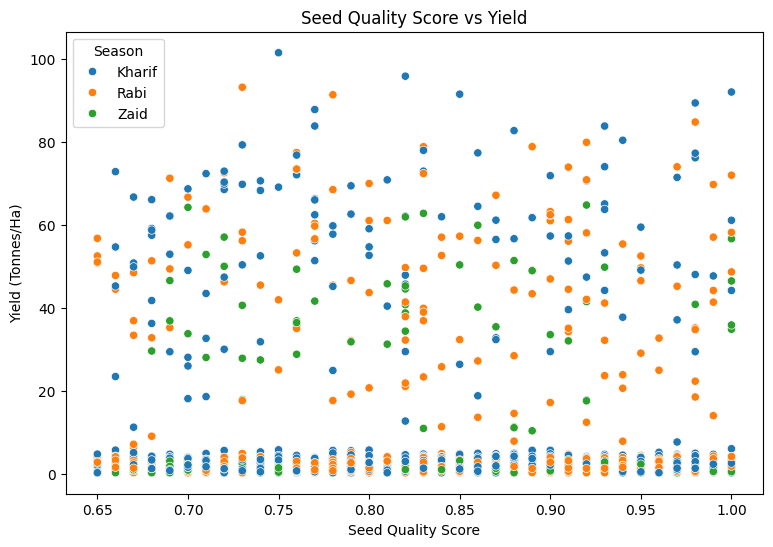

In [51]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Seed_Quality_Score',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Seed Quality Score vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [52]:
df[
    ['Seed_Quality_Score', 'Yield_Tonnes_Ha']
].corr()

,Seed_Quality_Score,Yield_Tonnes_Ha
Seed_Quality_Score,1.000000,-0.007209
Yield_Tonnes_Ha,-0.007209,1.000000


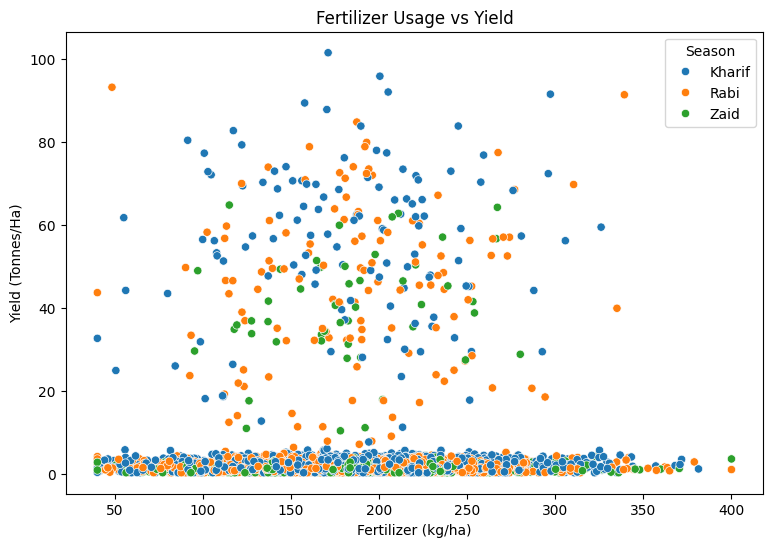

In [53]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.show()

In [54]:
df[
    ['Fertilizer_kg_ha', 'Yield_Tonnes_Ha']
].corr()

,Fertilizer_kg_ha,Yield_Tonnes_Ha
Fertilizer_kg_ha,1.000000,0.000018
Yield_Tonnes_Ha,0.000018,1.000000


In [55]:
final_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

final_summary.round(2)

,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.63,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


In [56]:
best_yield_season = season_yield.idxmax()
best_profit_season = season_profit.idxmax()
best_efficiency_season = water_efficiency.idxmax()
highest_risk_season = risk_by_season.idxmax()

print("Highest average yield:", best_yield_season)
print("Highest average profit:", best_profit_season)
print("Highest water efficiency:", best_efficiency_season)
print("Highest disease/pest risk:", highest_risk_season)

Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif
Highest disease/pest risk: Kharif
